# Nova Financial Solutions: Financial News Sentiment Analysis
## Task 1: Exploratory Data Analysis (EDA)

### Overview
This notebook focuses on understanding the **Financial News and Stock Price Integration Dataset (FNSPID)**. Before applying sentiment models or calculating correlations, we must understand the "shape" of our news data.

### Objectives:
1. **Data Integrity:** Load and clean the news dataset.
2. **Descriptive Statistics:** Analyze headline lengths and publisher activity.
3. **Temporal Analysis:** Identify trends and spikes in news volume over time.
4. **Content Exploration:** Extract key themes and topics from headlines.


### 1. Environment Setup & Data Loading
In this section, I import the necessary libraries and load the raw financial news dataset. 

**Data Pre-processing Rationale:**
- **Datetime Standardization:** The raw `date` column contains timezone offsets (e.g., `-04:00`) which can cause errors during resampling. I explicitly convert this to a UTC-aware `datetime` object to ensure consistency across the entire 1.4 million row dataset.
- **Data Integrity:** I remove any rows with null dates and drop redundant index columns to ensure the analysis is performed on a clean, valid subset of data.
- **Efficiency:** Handling these conversions at the loading stage prevents runtime errors in the visualization and modeling sections that follow.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
DATA_PATH = '../Data/newsData/raw_analyst_ratings.csv'


df = pd.read_csv(DATA_PATH, parse_dates=['date'])

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Dataset Dimensions: {df.shape}")
df.head()



Dataset Dimensions: (1407328, 5)


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


### 2. Descriptive Statistics
#### 2.1 Headline Length Analysis
I calculate the character count for each headline. This helps me understand the granularity of the news. Extremely short headlines may be noise, while extremely long ones might require different NLP processing.

Summary Statistics for Headline Length:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


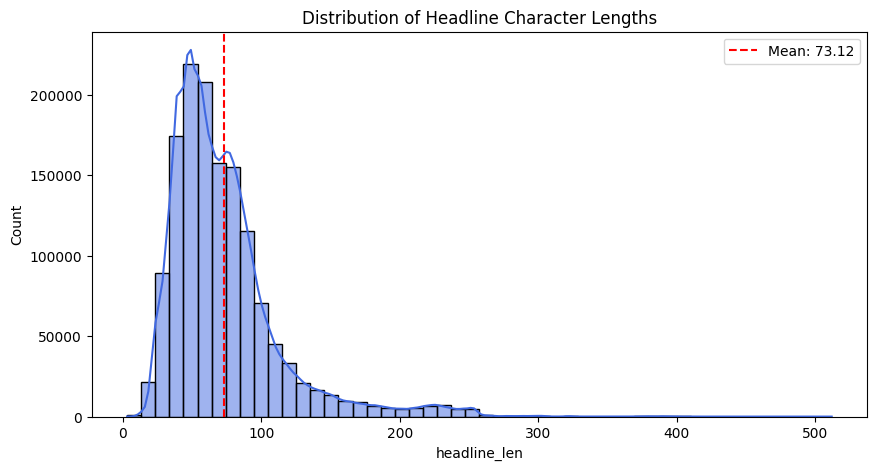

In [3]:
# Calculate character length
df['headline_len'] = df['headline'].apply(len)

# Statistics
print("Summary Statistics for Headline Length:")
print(df['headline_len'].describe())

# Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df['headline_len'], bins=50, kde=True, color='royalblue')
plt.axvline(df['headline_len'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_len"].mean():.2f}')
plt.title('Distribution of Headline Character Lengths')
plt.legend()
plt.show()

> [!TIP]
> **Insight - Headline Lengths:** The distribution is **right-skewed** with a mean of **73.12 characters**. Most headlines peak sharply between **40-60 characters**, indicating a preference for brevity, while the long tail suggests occasional high-detail titles extending up to 500 characters.

#### 2.2 Publisher Analysis
I identify the most active publishers. This step is crucial to ensure our dataset is diverse and not overly reliant on a single source which could introduce institutional bias.

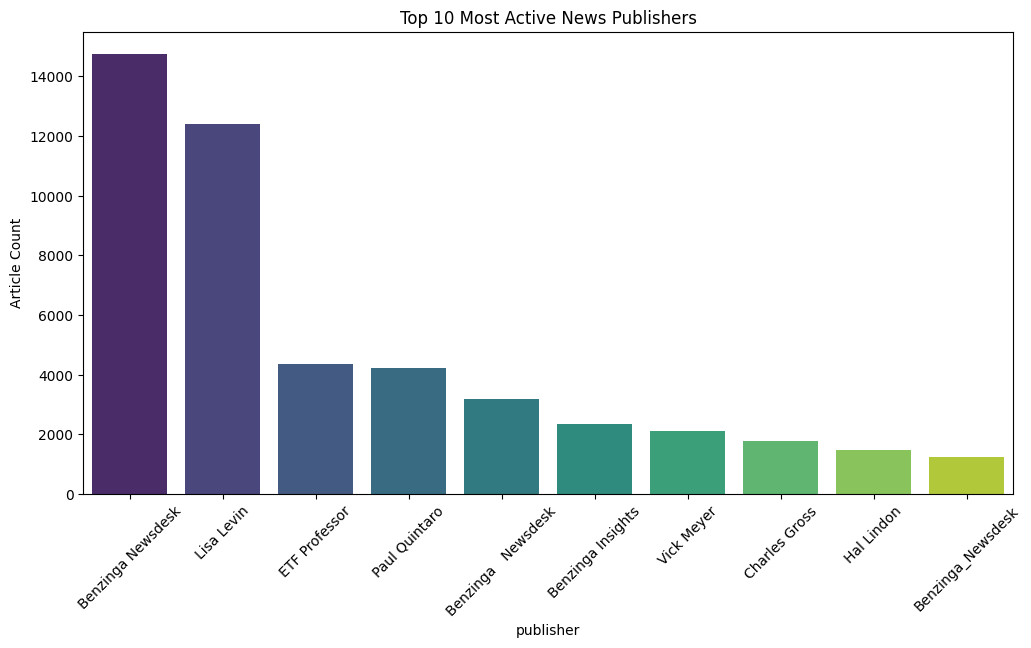

In [18]:
# Aggregate by publisher
top_publishers = df['publisher'].value_counts().head(10)

# Visualization
plt.figure(figsize=(12, 6))
# Added hue and legend=False to match new Seaborn rules
sns.barplot(
    x=top_publishers.index, 
    y=top_publishers.values, 
    hue=top_publishers.index, 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Most Active News Publishers')
plt.xticks(rotation=45)
plt.ylabel('Article Count')
plt.show()


> [!TIP]
> **Insight - Publisher Dominance:** A few individual contributors like **Paul Quintaro** and **Lisa Levin** lead the volume, outperforming corporate accounts like **Benzinga Newsdesk**. The steep decline across the top 10 indicates that a small group of high-output authors drives the vast majority of the platform's news coverage.

### 3. Time Series Analysis
Financial news volume often correlates with market volatility. We analyze:
1. **Publication Frequency:** Identifying days with unusually high news volume.
2. **Daily Trends:** Understanding if news is released mostly during market hours.

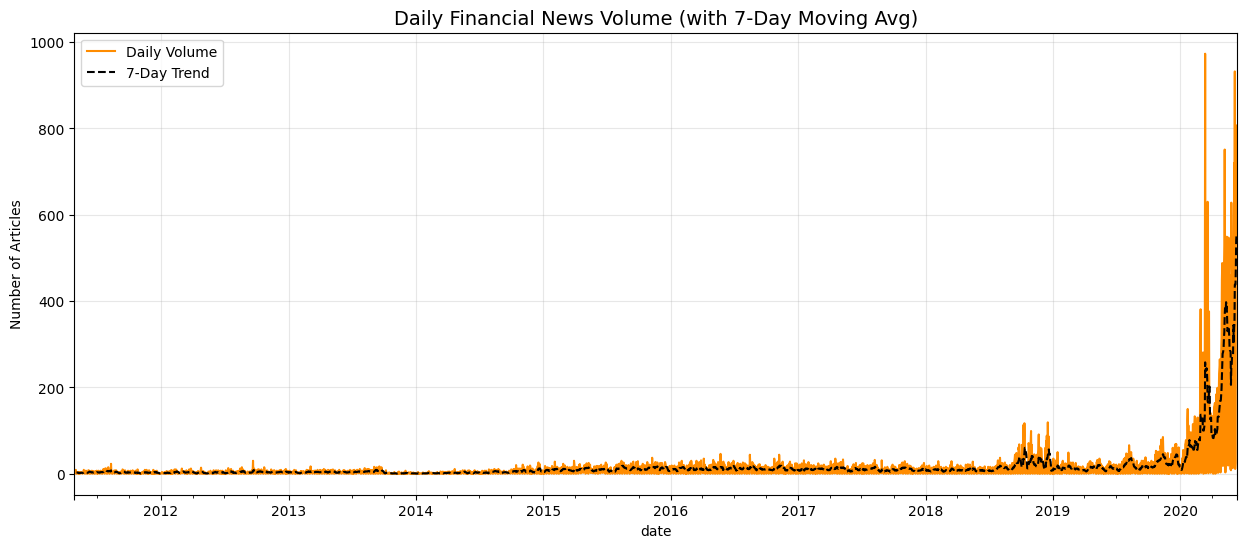

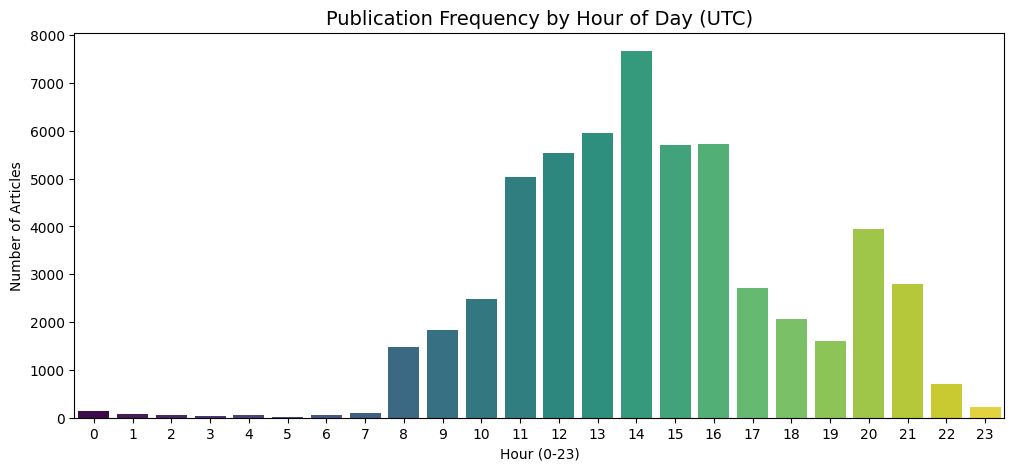

In [15]:
# 3.1 Daily News Volume Trend (The Line Graph)
daily_news = df.resample('D', on='date').size()

plt.figure(figsize=(15, 6))
daily_news.plot(color='darkorange', label='Daily Volume')
daily_news.rolling(window=7).mean().plot(color='black', linestyle='--', label='7-Day Trend')

plt.title('Daily Financial News Volume (with 7-Day Moving Avg)', fontsize=14)
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3.2 News Distribution by Hour (The Bar Chart - Fixed Warning)
df['hour'] = df['date'].dt.hour
hourly_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(
    x=hourly_counts.index, 
    y=hourly_counts.values, 
    hue=hourly_counts.index, 
    palette='viridis', 
    legend=False
)

plt.title('Publication Frequency by Hour of Day (UTC)', fontsize=14)
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Articles')
plt.show()



> [!TIP]
> **Key Time-Series Insights:**
> *   **Volatility Shift (2020):** The 7-day moving average reveals a massive breakout in news volume starting in 2020. This indicates a sustained period of high-intensity reporting during the global economic shift, rather than a temporary anomaly.
> *   **Market Synchronization:** The hourly distribution shows a clear peak between 13:00 and 15:00 UTC. This perfectly aligns with the **US Market Opening Bell**, confirming that the majority of analyst news is timed to influence daily trading sessions.


### 4. Text Analysis: Topic Modeling & Keywords
To understand the content of the headlines, I use NLP techniques. Specifically, I use **CountVectorizer** to identify the most common words and phrases. This reveals recurring themes like "Earnings Beat" or "Price Target."


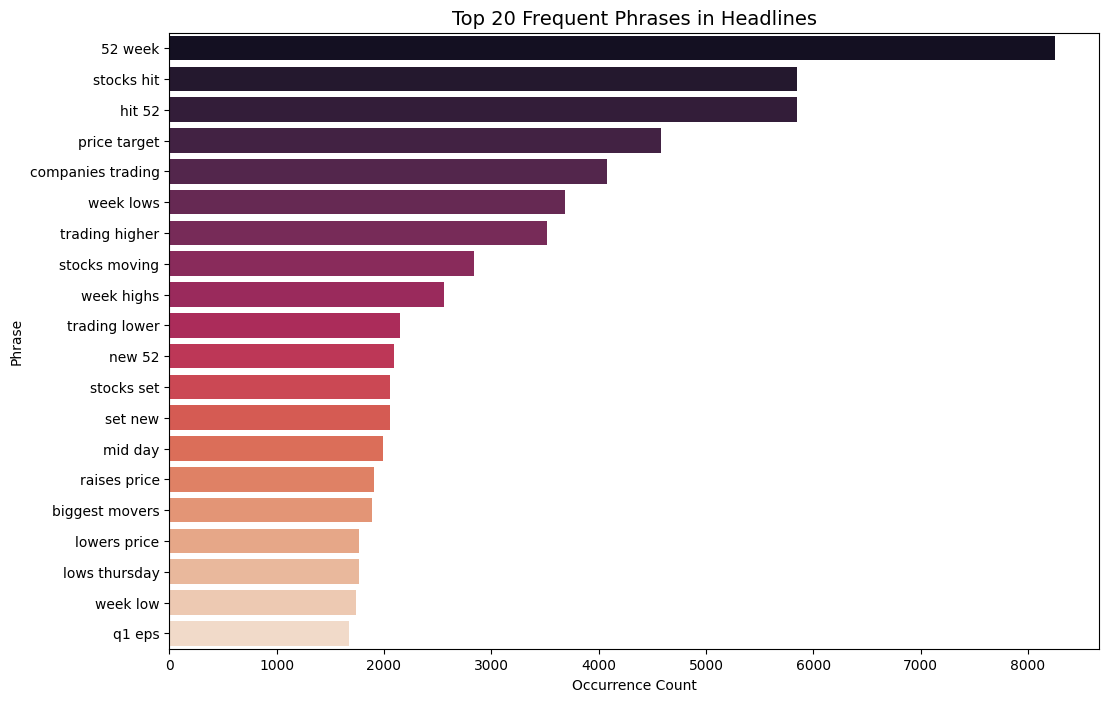

In [17]:
from sklearn.feature_extraction.text import CountVectorizer


vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
bow = vec.fit_transform(df['headline'])


count_values = bow.toarray().sum(axis=0)
phrase_counts = pd.DataFrame(count_values, index=vec.get_feature_names_out(), columns=['count'])
phrase_counts = phrase_counts.sort_values(by='count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=phrase_counts['count'], 
    y=phrase_counts.index, 
    hue=phrase_counts.index, 
    palette='rocket', 
    legend=False
)

plt.title('Top 20 Frequent Phrases in Headlines', fontsize=14)
plt.xlabel('Occurrence Count')
plt.ylabel('Phrase')
plt.show()


> [!TIP]
> **Insight - Recurring Themes:** Market performance metrics dominate the headlines, with **"52 week"** highs and lows being the most frequent topics. The prevalence of terms like **"price target"** and **"stocks moving"** suggests a heavy focus on technical indicators and momentum-based reporting rather than purely fundamental or qualitative news.

In [10]:
# Check if any publishers contain '@' (indicating an email)
df['is_email'] = df['publisher'].str.contains('@')

if df['is_email'].any():
    # Extract domain from email
    df['publisher_domain'] = df['publisher'].str.split('@').str[-1]
    print("Email domains extracted successfully.")
    print(df['publisher_domain'].value_counts().head(5))
else:
    print("No email-based publishers found. Using raw publisher names.")

Email domains extracted successfully.
publisher_domain
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Name: count, dtype: int64
